# Bodrum Hotel & Destination Intelligence
## 02 - Data Audit

Data Audit, temizliğe başlamadan önce veri setinin mevcut durumunu sistematik biçimde ölçer.
Eksik değerler, duplicate kayıtlar, tutarsız kategoriler, mantıksız nicel değerler, veri tipi
sorunları ve kapsam yetersizlikleri tespit edilir.

Bu notebook sorunları yalnızca **tespit eder ve raporlar**. Hiçbir değer doldurulmaz, düzeltilmez
veya silinmez. Düzeltmeler planlanan `03_data_cleaning.ipynb` aşamasına bırakılmıştır.

### 1. Kurulum ve veri setlerinin yüklenmesi

Gerekli temel kütüphaneler yüklenir; proje dosyaları farklı çalışma dizinleri için güvenli biçimde
aranır. Telefon alanı biçimini korumak üzere metin olarak okunur. Ana veri seti değiştirilmez.

In [1]:
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd().resolve()

def find_project_file(file_name, required=True):
    roots = [PROJECT_ROOT, PROJECT_ROOT.parent]
    candidates = []
    for root in roots:
        candidates.extend([root / file_name, root / "data" / file_name, root / "data" / "raw" / file_name])
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    if required:
        searched = "\n".join(f"- {path}" for path in candidates)
        raise FileNotFoundError(f"'{file_name}' bulunamadı. Aranan konumlar:\n{searched}")
    return None

MASTER_PATH = find_project_file("bodrum_hotels_master_2026-08-24.csv")
PROJECT_BASE = MASTER_PATH.parent
if PROJECT_BASE.name == "raw" and PROJECT_BASE.parent.name == "data":
    PROJECT_BASE = PROJECT_BASE.parent.parent
REPORTS_DIR = PROJECT_BASE / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(MASTER_PATH, dtype={"phone": "string"})
df["area_hotel_count"] = df.groupby("area")["hotel_id"].transform("size")


### 2. Genel veri seti sağlığı

Boyut, bellek kullanımı, eksiklik, tam satır duplicate sayısı, temel kimlik benzersizliği ve
destinasyon kapsamı tek bir özet tabloda birleştirilir.

In [2]:
total_cells = int(df.size)
missing_cells = int(df.isna().sum().sum())
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

audit_summary = pd.DataFrame([
    ("rows", len(df)),
    ("columns", df.shape[1]),
    ("total_cells", total_cells),
    ("missing_cells", missing_cells),
    ("missing_percentage", 100 * missing_cells / total_cells if total_cells else 0),
    ("duplicate_rows", int(df.duplicated().sum())),
    ("unique_hotel_id", int(df["hotel_id"].nunique(dropna=True))),
    ("unique_place_id", int(df["place_id"].nunique(dropna=True))),
    ("destination_count", int(df["area"].nunique(dropna=True))),
    ("memory_usage_mb", memory_mb),
], columns=["metric", "value"])

display(audit_summary)
display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))

,metric,value
0,rows,192.00
1,columns,20.00
2,total_cells,"3,840.00"
3,missing_cells,435.00
4,missing_percentage,11.33
5,duplicate_rows,0.00
6,unique_hotel_id,192.00
7,unique_place_id,192.00
8,destination_count,14.00
9,memory_usage_mb,0.26


,column,dtype
0,hotel_id,object
1,place_id,object
2,hotel_name,object
3,area,object
4,district,object
5,province,object
6,country,object
7,property_category,object
8,official_star_rating,float64
9,google_rating,float64


### 3. Eksik değer analizi

Her kolonun eksik ve dolu gözlem sayısı ile eksiklik oranı hesaplanır. Grafik yalnızca gerçekten
eksik değer içeren kolonları gösterir; hiçbir değer doldurulmaz.

,column,missing_count,missing_percentage,non_missing_count
0,official_star_rating,192,100.00,0
1,business_status,191,99.48,1
2,price_note,24,12.50,168
3,search_price_usd_snapshot,24,12.50,168
4,phone,4,2.08,188
5,address,0,0.00,192
6,area,0,0.00,192
7,area_hotel_count,0,0.00,192
8,collected_at,0,0.00,192
9,country,0,0.00,192


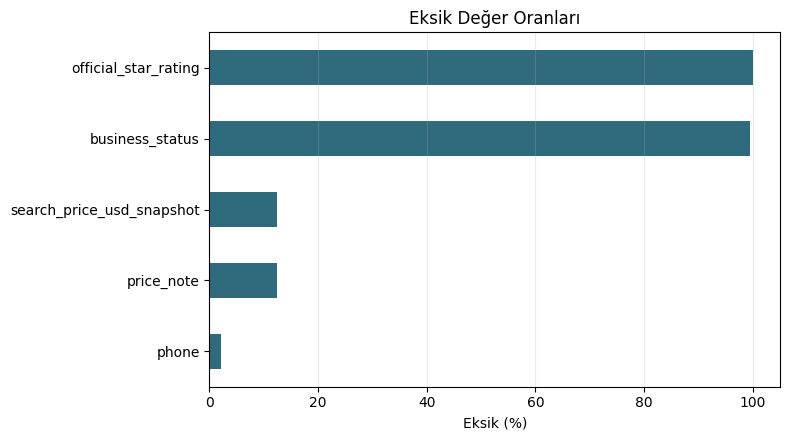

,column,missing_count,missing_percentage,non_missing_count
0,official_star_rating,192,100.00,0
1,business_status,191,99.48,1
3,search_price_usd_snapshot,24,12.50,168
4,phone,4,2.08,188


In [3]:
missing_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100),
    "non_missing_count": df.notna().sum().values,
}).sort_values(["missing_percentage", "column"], ascending=[False, True], ignore_index=True)

display(missing_report)

missing_plot = missing_report.loc[missing_report["missing_count"] > 0].sort_values("missing_percentage")
if not missing_plot.empty:
    ax = missing_plot.plot.barh(
        x="column", y="missing_percentage", legend=False, color="#2F6B7C", figsize=(8, 4.5)
    )
    ax.set(title="Eksik Değer Oranları", xlabel="Eksik (%)", ylabel="")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

focus_columns = ["official_star_rating", "search_price_usd_snapshot", "phone", "business_status"]
display(missing_report.query("column in @focus_columns and missing_count > 0"))

### 4. Duplicate kontrolü

Tam satır, `hotel_id`, `place_id`, ham otel adı ve yalnızca audit için oluşturulan normalize otel
adı ayrı ayrı kontrol edilir. Normalizasyon küçük harfe çevirme, kenar boşluklarını temizleme,
temel noktalama işaretlerini kaldırma ve çoklu boşlukları teke indirme ile sınırlıdır; ana veri
setine yeni kolon eklenmez ve hiçbir kayıt silinmez.

In [4]:
def normalize_text(series):
    return (
        series.astype("string")
        .str.lower()
        .str.strip()
        .str.replace(r"[^\w\s]", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
    )

normalized_name = normalize_text(df["hotel_name"])
duplicate_masks = {
    "full_row": df.duplicated(keep=False),
    "hotel_id": df["hotel_id"].duplicated(keep=False) & df["hotel_id"].notna(),
    "place_id": df["place_id"].duplicated(keep=False) & df["place_id"].notna(),
    "hotel_name": df["hotel_name"].duplicated(keep=False) & df["hotel_name"].notna(),
    "normalized_hotel_name": normalized_name.duplicated(keep=False) & normalized_name.notna(),
}

duplicate_overview = pd.DataFrame([
    {"duplicate_level": level, "affected_rows": int(mask.sum())}
    for level, mask in duplicate_masks.items()
])
display(duplicate_overview)

duplicate_parts = []
report_columns = ["duplicate_type", "key_value", "row_index", "hotel_id", "place_id", "hotel_name", "area"]
for level, mask in duplicate_masks.items():
    if mask.any():
        part = df.loc[mask, ["hotel_id", "place_id", "hotel_name", "area"]].copy()
        part.insert(0, "row_index", part.index)
        if level == "full_row":
            key = pd.Series("identical_full_row", index=part.index)
        elif level == "normalized_hotel_name":
            key = normalized_name.loc[mask]
        else:
            key = df.loc[mask, level]
        part.insert(0, "key_value", key.astype("string"))
        part.insert(0, "duplicate_type", level)
        duplicate_parts.append(part)

duplicate_report = (
    pd.concat(duplicate_parts, ignore_index=True)[report_columns]
    if duplicate_parts else pd.DataFrame(columns=report_columns)
)
display(duplicate_report)

,duplicate_level,affected_rows
0,full_row,0
1,hotel_id,0
2,place_id,0
3,hotel_name,0
4,normalized_hotel_name,0


,duplicate_type,key_value,row_index,hotel_id,place_id,hotel_name,area


### 5. ID bütünlüğü

Otel ve Google Place kimliklerinin eksikliği ve benzersizliği ölçülür. `hotel_id` için beklenen
`BOD` + üç rakam biçimi regex ile test edilir.

In [5]:
hotel_id_format_valid = df["hotel_id"].astype("string").str.fullmatch(r"BOD\d{3}", na=False)
id_integrity = pd.DataFrame([
    ("hotel_id_missing", int(df["hotel_id"].isna().sum())),
    ("hotel_id_duplicate_rows", int(duplicate_masks["hotel_id"].sum())),
    ("hotel_id_invalid_format", int((~hotel_id_format_valid).sum())),
    ("hotel_id_is_unique", bool(df["hotel_id"].is_unique)),
    ("place_id_missing", int(df["place_id"].isna().sum())),
    ("place_id_duplicate_rows", int(duplicate_masks["place_id"].sum())),
    ("place_id_is_unique", bool(df["place_id"].is_unique)),
], columns=["check", "value"])
id_integrity

,check,value
0,hotel_id_missing,0
1,hotel_id_duplicate_rows,0
2,hotel_id_invalid_format,0
3,hotel_id_is_unique,True
4,place_id_missing,0
5,place_id_duplicate_rows,0
6,place_id_is_unique,True


### 6. Google Rating audit

`google_rating`, müşteri değerlendirme puanıdır ve resmî yıldız sınıfından tamamen farklıdır.
Dağılım istatistikleri ile 0-5 geçerlilik aralığı ve `google_rating_scale == 5` kuralı denetlenir.

In [6]:
rating = pd.to_numeric(df["google_rating"], errors="coerce")
rating_stats = pd.DataFrame([
    ("dtype", str(df["google_rating"].dtype)),
    ("missing", int(rating.isna().sum())),
    ("min", rating.min()), ("max", rating.max()), ("mean", rating.mean()),
    ("median", rating.median()), ("std", rating.std()),
    ("q1", rating.quantile(0.25)), ("q3", rating.quantile(0.75)),
], columns=["metric", "value"])
invalid_rating = df.loc[rating.notna() & ~rating.between(0, 5)]
invalid_scale = df.loc[df["google_rating_scale"].ne(5) | df["google_rating_scale"].isna()]

display(rating_stats)
display(pd.DataFrame({"check": ["rating_out_of_range", "rating_scale_not_5"],
                      "issue_count": [len(invalid_rating), len(invalid_scale)]}))
display(invalid_rating[["hotel_id", "hotel_name", "google_rating", "google_rating_scale"]])

,metric,value
0,dtype,float64
1,missing,0
2,min,3.20
3,max,5.00
4,mean,4.36
5,median,4.40
6,std,0.33
7,q1,4.20
8,q3,4.60


,check,issue_count
0,rating_out_of_range,0
1,rating_scale_not_5,0


,hotel_id,hotel_name,google_rating,google_rating_scale


### 7. Google yorum sayısı audit

Yorum sayısının temel istatistikleri, sıfır/negatif/eksik değerleri kontrol edilir. Sağ kuyruklu
dağılımı okunabilir kılmak için yalnızca grafikte `log1p` görünümü kullanılır; veri değiştirilmez.

,metric,value
0,min,33.00
1,max,"13,412.00"
2,median,466.00
3,mean,"1,066.89"
4,zero_count,0.00
5,negative_count,0.00
6,missing_count,0.00


,hotel_id,hotel_name,google_review_count


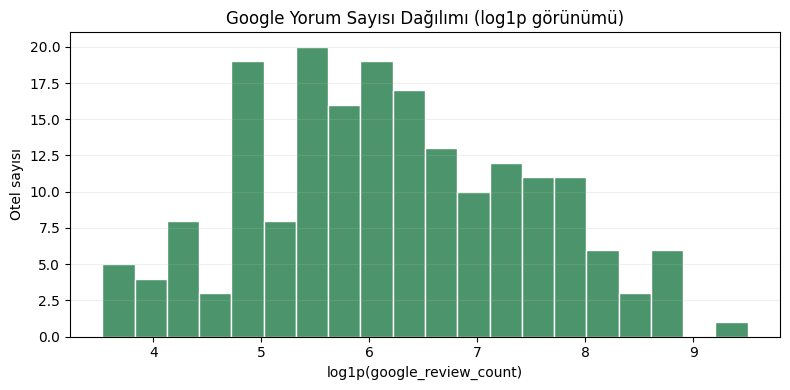

In [7]:
reviews = pd.to_numeric(df["google_review_count"], errors="coerce")
review_stats = pd.DataFrame([
    ("min", reviews.min()), ("max", reviews.max()), ("median", reviews.median()),
    ("mean", reviews.mean()), ("zero_count", int(reviews.eq(0).sum())),
    ("negative_count", int(reviews.lt(0).sum())), ("missing_count", int(reviews.isna().sum())),
], columns=["metric", "value"])
display(review_stats)
display(df.loc[reviews.lt(0), ["hotel_id", "hotel_name", "google_review_count"]])

ax = np.log1p(reviews.dropna()).plot.hist(bins=20, color="#4C956C", edgecolor="white", figsize=(8, 4))
ax.set(title="Google Yorum Sayısı Dağılımı (log1p görünümü)", xlabel="log1p(google_review_count)", ylabel="Otel sayısı")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

### 8. Fiyat snapshot audit

`search_price_usd_snapshot` sabit veya gerçek otel fiyatı değildir. Tarih, oda tipi, konaklama
süresi ve kişi sayısı bağlamı olmadan doğrudan fiyat modellemesinde kullanımı sınırlıdır.
IQR yöntemi potansiyel uç değerleri yalnızca işaretler; değerler silinmez veya düzeltilmez.

In [8]:
price = pd.to_numeric(df["search_price_usd_snapshot"], errors="coerce")
price_q1, price_q3 = price.quantile([0.25, 0.75])
price_iqr = price_q3 - price_q1
price_lower = price_q1 - 1.5 * price_iqr
price_upper = price_q3 + 1.5 * price_iqr
price_outlier_mask = price.notna() & ((price < price_lower) | (price > price_upper))

price_stats = pd.DataFrame([
    ("missing_percentage", price.isna().mean() * 100),
    ("min", price.min()), ("max", price.max()), ("median", price.median()),
    ("mean", price.mean()), ("q1", price_q1), ("q3", price_q3),
    ("iqr", price_iqr), ("lower_fence", price_lower), ("upper_fence", price_upper),
    ("potential_outlier_count", int(price_outlier_mask.sum())),
], columns=["metric", "value"])
outlier_price_report = df.loc[price_outlier_mask,
    ["hotel_name", "area", "search_price_usd_snapshot", "google_rating", "google_review_count"]
].sort_values("search_price_usd_snapshot", ascending=False).reset_index(drop=True)

display(price_stats)
display(outlier_price_report)

,metric,value
0,missing_percentage,12.50
1,min,57.00
2,max,"3,158.00"
3,median,168.00
4,mean,291.51
5,q1,117.00
6,q3,301.75
7,iqr,184.75
8,lower_fence,-160.12
9,upper_fence,578.88


,hotel_name,area,search_price_usd_snapshot,google_rating,google_review_count
0,Caja by Maxx Royal,Türkbükü,"3,158.00",4.60,135
1,Voyage Torba,Torba,"2,660.00",4.70,2753
2,Voyage Torba Private,Torba,"2,489.00",4.70,548
3,"Mandarin Oriental, Bodrum",Göltürkbükü,"1,679.00",4.70,2728
4,"Caresse, a Luxury Collection Resort & Spa, Bodrum",Bitez,"1,654.00",4.50,904
5,Xanadu Island,Akyarlar,"1,301.00",4.60,2068
6,Azure By Yelken Hotel,Kadıkalesi,962.00,4.40,565
7,The Bodrum EDITION,Yalıkavak,841.00,4.40,1016
8,Yalıkavak Marina Hotel by METT Collection,Yalıkavak,832.00,4.80,267
9,MACAKIZI BODRUM,Türkbükü,805.00,4.30,1247


### 9. Kategorik kolon audit

Temel kategorilerin benzersiz değer sayıları ve frekansları gösterilir. Yazım tutarsızlığı için
boşluk, noktalama ve büyük/küçük harf farklarını yok sayan geçici anahtarlar karşılaştırılır.
Benzer görünen destinasyonlar (ör. Göltürkbükü ve Türkbükü) otomatik olarak birleştirilmez.

In [9]:
categorical_columns = ["area", "district", "province", "country", "property_category", "business_status"]
category_summary = pd.DataFrame([
    {"column": column, "unique_count": int(df[column].nunique(dropna=True)),
     "missing_count": int(df[column].isna().sum())}
    for column in categorical_columns
])
display(category_summary)

def category_variants(series):
    frame = pd.DataFrame({"original": series.dropna().astype("string").unique()})
    frame["audit_key"] = normalize_text(frame["original"])
    return frame[frame.duplicated("audit_key", keep=False)].sort_values("audit_key")

for column in categorical_columns:
    display(Markdown(f"**{column} değer dağılımı**"))
    display(df[column].value_counts(dropna=False).rename_axis("value").reset_index(name="count"))
    variants = category_variants(df[column])
    if not variants.empty:
        display(Markdown("Olası yazım/biçim varyantları:"))
        display(variants)

,column,unique_count,missing_count
0,area,14,0
1,district,1,0
2,province,1,0
3,country,1,0
4,property_category,13,0
5,business_status,1,191


**area değer dağılımı**

,value,count
0,Yalıkavak,22
1,Ortakent-Yahşi,21
2,Torba,21
3,Bitez,18
4,Akyarlar,16
5,Gümbet,15
6,Gümüşlük,15
7,Gündoğan,14
8,Bodrum Merkez,13
9,Göltürkbükü,10


**district değer dağılımı**

,value,count
0,Bodrum,192


...

,value,count
0,Türkiye,192


**property_category değer dağılımı**

,value,count
0,Otel,174
1,Resort Otel,5
2,Oda Kahvaltı,2
3,Uzun Süreli Kalmaya Uygun Otel,2
4,Villa,1
5,Turistik Pansiyon,1
6,Günlük Kiralık Daire,1
7,Kat Hizmeti Sunulan Konaklama,1
8,Motel,1
9,Doğa Köşkü,1


**business_status değer dağılımı**

,value,count
0,NaN,191
1,Temporarily Closed,1


### 10. Coğrafi / destinasyon kapsamı

Bölge bilgisi ayrı bir özet dosyasından alınmaz. `area_hotel_count` ana `df` içinde bulunur; ayrıntılı destinasyon raporu da aynı tablo üzerinden hesaplanır. `hotel_count < 5` olan bölgeler karşılaştırmalarda örneklem hassasiyeti nedeniyle işaretlenir.

In [10]:
destination_coverage_report = (
    df.groupby("area", dropna=False)
    .agg(
        hotel_count=("hotel_id", "size"),
        avg_google_rating=("google_rating", "mean"),
        median_google_rating=("google_rating", "median"),
        total_google_reviews=("google_review_count", "sum"),
        median_price_snapshot=("search_price_usd_snapshot", "median"),
    )
    .reset_index()
    .sort_values(["hotel_count", "area"], ascending=[True, True])
)
destination_coverage_report["low_sample_area"] = destination_coverage_report["hotel_count"] < 5
destination_coverage_report

,area,hotel_count,avg_google_rating,median_google_rating,total_google_reviews,median_price_snapshot,low_sample_area
8,Kadıkalesi,4,4.30,4.35,11520,446.00,True
12,Türkbükü,6,4.45,4.45,3670,532.00,False
11,Turgutreis,7,4.43,4.60,14095,123.50,False
3,Göltürkbükü,10,4.48,4.45,6008,165.00,False
7,Güvercinlik,10,4.16,4.25,25239,162.50,False
2,Bodrum Merkez,13,4.30,4.30,18174,169.00,False
6,Gündoğan,14,4.59,4.50,6520,189.50,False
4,Gümbet,15,4.09,4.00,32519,128.00,False
5,Gümüşlük,15,4.51,4.50,4166,106.00,False
0,Akyarlar,16,4.45,4.40,27426,192.50,False


### 11. Resmî yıldız bilgisi audit

Resmî yıldız sınıfının doluluk ve 1-5 aralığı kontrol edilir. Google müşteri puanından yıldız
türetilmez. Yüksek eksiklik oranı, daha sonra güvenilir dış kaynakla zenginleştirme ihtiyacı olarak
raporlanır.

In [11]:
official_stars = pd.to_numeric(df["official_star_rating"], errors="coerce")
invalid_star_mask = official_stars.notna() & ~official_stars.between(1, 5)
star_missing_pct = official_stars.isna().mean() * 100
star_audit = pd.DataFrame([
    ("non_missing_count", int(official_stars.notna().sum())),
    ("missing_count", int(official_stars.isna().sum())),
    ("missing_percentage", star_missing_pct),
    ("out_of_range_count", int(invalid_star_mask.sum())),
    ("enrichment_priority", "HIGH" if star_missing_pct >= 50 else "MEDIUM" if star_missing_pct > 0 else "LOW"),
], columns=["metric", "value"])
display(star_audit)
display(df.loc[invalid_star_mask, ["hotel_id", "hotel_name", "official_star_rating"]])

,metric,value
0,non_missing_count,0
1,missing_count,192
2,missing_percentage,100.00
3,out_of_range_count,0
4,enrichment_priority,HIGH


,hotel_id,hotel_name,official_star_rating


### 12. Telefon ve adres audit

Telefonlarda eksiklik, duplicate ve kaba biçim; adreslerde eksiklik, duplicate, kısa metin ve
Bodrum/Muğla kapsamı kontrol edilir. Bu alanlar yalnızca raporlanır, formatları değiştirilmez.

In [12]:
phone_text = df["phone"].astype("string")
phone_format_valid = phone_text.str.fullmatch(r"\+?\d{10,15}", na=False)
phone_duplicate_mask = phone_text.notna() & phone_text.duplicated(keep=False)

address_text = df["address"].astype("string")
address_duplicate_mask = address_text.notna() & address_text.duplicated(keep=False)
short_address_mask = address_text.notna() & address_text.str.len().lt(10)
bodrum_mugla_mask = address_text.str.contains(r"Bodrum|Muğla|Mugla", case=False, regex=True, na=False)

contact_audit = pd.DataFrame([
    ("phone_missing", int(phone_text.isna().sum())),
    ("phone_duplicate_rows", int(phone_duplicate_mask.sum())),
    ("phone_invalid_format", int((phone_text.notna() & ~phone_format_valid).sum())),
    ("address_missing", int(address_text.isna().sum())),
    ("address_duplicate_rows", int(address_duplicate_mask.sum())),
    ("address_too_short", int(short_address_mask.sum())),
    ("address_without_bodrum_or_mugla", int((address_text.notna() & ~bodrum_mugla_mask).sum())),
], columns=["check", "issue_count"])
display(contact_audit)
display(df.loc[phone_duplicate_mask | (phone_text.notna() & ~phone_format_valid),
                   ["hotel_id", "hotel_name", "phone"]])
display(df.loc[address_duplicate_mask | short_address_mask | (address_text.notna() & ~bodrum_mugla_mask),
                   ["hotel_id", "hotel_name", "address"]])

,check,issue_count
0,phone_missing,4
1,phone_duplicate_rows,8
2,phone_invalid_format,1
3,address_missing,0
4,address_duplicate_rows,2
5,address_too_short,0
6,address_without_bodrum_or_mugla,1


,hotel_id,hotel_name,phone
18,BOD019,Bitez Garden Life Hotel&Suites,+902523131111
137,BOD138,Bodrum Blue Bay Otel,+905308346979
145,BOD146,Olivia Hotel,+905308346979
155,BOD156,Voyage Torba,+902523671820
156,BOD157,Voyage Torba Private,+902523671820
157,BOD158,Arin Resort Bodrum,+902523828898
162,BOD163,Sundance Resort,+902523828898
164,BOD165,Caja by Maxx Royal,+904443020
191,BOD192,Yalıpark Beach Hotel,+902523131111


,hotel_id,hotel_name,address
18,BOD019,Bitez Garden Life Hotel&Suites,"Bitez, Bergamut Cd. No:52, 48400 Bodrum/Muğla, Türkiye"
26,BOD027,Meis Apart Hotel,"Bitez, Bergamut Cd. No:52, 48400 Bodrum/Muğla, Türkiye"
83,BOD084,Paradise Garden Apartments,"Yali Mevkii Gumusluk, Armonia Evleri, 48400, Türkiye"


### 13. Tarih / snapshot audit

`collected_at` alanı geçersiz değerleri zorla `NaT` yaparak test amaçlı parse edilir. Dönüşüm
yalnızca geçici seride yapılır; ana kolona yazılmaz. Tek snapshot tarihi varsa açıkça gösterilir.

In [13]:
collected_at_parsed = pd.to_datetime(df["collected_at"], errors="coerce")
invalid_date_mask = df["collected_at"].notna() & collected_at_parsed.isna()
date_audit = pd.DataFrame([
    ("missing_count", int(df["collected_at"].isna().sum())),
    ("invalid_date_count", int(invalid_date_mask.sum())),
    ("unique_valid_snapshot_dates", int(collected_at_parsed.dt.date.nunique())),
    ("single_snapshot_date", bool(collected_at_parsed.dt.date.nunique() == 1)),
    ("min_snapshot", collected_at_parsed.min()),
    ("max_snapshot", collected_at_parsed.max()),
], columns=["metric", "value"])
display(date_audit)
display(df.loc[invalid_date_mask, ["hotel_id", "hotel_name", "collected_at"]])

,metric,value
0,missing_count,0
1,invalid_date_count,0
2,unique_valid_snapshot_dates,1
3,single_snapshot_date,True
4,min_snapshot,2026-08-24 00:00:00
5,max_snapshot,2026-08-24 00:00:00


,hotel_id,hotel_name,collected_at


### 14. Kaynak audit

Kaynak URL'lerinin eksikliği, benzersizlik oranı ve kaba HTTP(S) formatı kontrol edilir. Ayrıca
her satırdaki `place_id` değerinin ilgili Google Maps URL'sinde yer alması beklenir.

In [14]:
source_text = df["source_url"].astype("string")
valid_url_mask = source_text.str.match(r"^https?://", na=False)
place_source_consistent = pd.Series([
    pd.notna(place_id) and pd.notna(url) and str(place_id) in str(url)
    for place_id, url in zip(df["place_id"], df["source_url"])
], index=df.index)

source_audit = pd.DataFrame([
    ("source_url_missing", int(source_text.isna().sum())),
    ("source_url_unique_count", int(source_text.nunique(dropna=True))),
    ("source_url_unique_ratio", source_text.nunique(dropna=True) / len(df) if len(df) else 0),
    ("invalid_url_format", int((source_text.notna() & ~valid_url_mask).sum())),
    ("place_id_url_mismatch", int((~place_source_consistent).sum())),
], columns=["metric", "value"])
display(source_audit)
display(df.loc[~place_source_consistent, ["hotel_id", "place_id", "source_url"]])

,metric,value
0,source_url_missing,0.00
1,source_url_unique_count,192.00
2,source_url_unique_ratio,1.00
3,invalid_url_format,0.00
4,place_id_url_mismatch,0.00


,hotel_id,place_id,source_url


### 15. Alanlar arası mantık kontrolleri

Önceden tanımlı iş kuralları tek tabloda uygulanır. Temel kimlik ve sayısal geçerlilik ihlalleri
oluşursa `FAIL`; beklenen sabit coğrafya veya bağlam ihlalleri oluşursa `WARNING`; sorun yoksa
`PASS` kullanılır.

In [15]:
check_definitions = [
    ("google_rating_above_scale", rating.notna() & df["google_rating_scale"].notna() & rating.gt(df["google_rating_scale"]), "FAIL"),
    ("google_rating_below_zero", rating.lt(0), "FAIL"),
    ("google_review_count_negative", reviews.lt(0), "FAIL"),
    ("search_price_non_positive", price.notna() & price.le(0), "WARNING"),
    ("official_star_out_of_range", invalid_star_mask, "FAIL"),
    ("district_not_bodrum", df["district"].notna() & df["district"].ne("Bodrum"), "WARNING"),
    ("province_not_mugla", df["province"].notna() & df["province"].ne("Muğla"), "WARNING"),
    ("country_not_turkiye", df["country"].notna() & df["country"].ne("Türkiye"), "WARNING"),
    ("hotel_id_duplicate", duplicate_masks["hotel_id"], "FAIL"),
    ("place_id_duplicate", duplicate_masks["place_id"], "FAIL"),
]

audit_checks = pd.DataFrame([
    {"check_name": name, "issue_count": int(mask.fillna(False).sum()),
     "status": severity if int(mask.fillna(False).sum()) > 0 else "PASS"}
    for name, mask, severity in check_definitions
])
audit_checks

,check_name,issue_count,status
0,google_rating_above_scale,0,PASS
1,google_rating_below_zero,0,PASS
2,google_review_count_negative,0,PASS
3,search_price_non_positive,0,PASS
4,official_star_out_of_range,0,PASS
5,district_not_bodrum,0,PASS
6,province_not_mugla,0,PASS
7,country_not_turkiye,0,PASS
8,hotel_id_duplicate,0,PASS
9,place_id_duplicate,0,PASS


### 16. Açıklanabilir Data Quality Score

Kalite skoru beş boyuttan türetilir: genel hücre doluluğu (%30), tam satır ve temel anahtar
benzersizliği (%20), uygulanabilir sayısal/tarih kurallarının geçerliliği (%25), temel coğrafya ve
puan ölçeği tutarlılığı (%15), Place ID ile geçerli kaynak URL kapsamı (%10). Alt skorlar 0-100
aralığına sıkıştırılır ve ağırlıklı ortalama alınır. Skor, bağlamsal fiyat sınırlaması gibi CSV'den
ölçülemeyen kavramların yerini tutmaz.

In [16]:
completeness_score = 100 * df.notna().sum().sum() / total_cells if total_cells else 0

uniqueness_rates = [
    1 - df.duplicated().mean(),
    1 - df["hotel_id"].duplicated(keep=False).mean(),
    1 - df["place_id"].duplicated(keep=False).mean(),
    1 - normalized_name.duplicated(keep=False).mean(),
]
uniqueness_score = 100 * np.mean(uniqueness_rates)

validity_checks = [
    rating.isna() | rating.between(0, 5),
    df["google_rating_scale"].isna() | df["google_rating_scale"].eq(5),
    reviews.isna() | reviews.ge(0),
    price.isna() | price.gt(0),
    official_stars.isna() | official_stars.between(1, 5),
    df["collected_at"].isna() | collected_at_parsed.notna(),
]
validity_score = 100 * np.mean([check.mean() for check in validity_checks])

consistency_checks = [
    df["district"].isna() | df["district"].eq("Bodrum"),
    df["province"].isna() | df["province"].eq("Muğla"),
    df["country"].isna() | df["country"].eq("Türkiye"),
    df["google_rating_scale"].isna() | df["google_rating_scale"].eq(5),
]
consistency_score = 100 * np.mean([check.mean() for check in consistency_checks])
source_coverage_score = 100 * np.mean([
    df["place_id"].notna().mean(),
    source_text.notna().mean(),
    valid_url_mask.mean(),
    place_source_consistent.mean(),
])

quality_dimensions = [
    ("Completeness", completeness_score, 0.30),
    ("Uniqueness", uniqueness_score, 0.20),
    ("Validity", validity_score, 0.25),
    ("Consistency", consistency_score, 0.15),
    ("Source coverage", source_coverage_score, 0.10),
]
data_quality_score = pd.DataFrame(quality_dimensions, columns=["dimension", "score", "weight"])
data_quality_score["weighted_score"] = data_quality_score["score"] * data_quality_score["weight"]
final_quality_score = float(data_quality_score["weighted_score"].sum())

def quality_label(score):
    if score >= 90: return "Excellent"
    if score >= 80: return "Good"
    if score >= 70: return "Acceptable"
    if score >= 60: return "Needs Improvement"
    return "Poor"

display(data_quality_score)
display(Markdown(f"### DATA QUALITY SCORE = {final_quality_score:.2f} / 100 — {quality_label(final_quality_score)}"))

,dimension,score,weight,weighted_score
0,Completeness,88.67,0.30,26.60
1,Uniqueness,100.00,0.20,20.00
2,Validity,100.00,0.25,25.00
3,Consistency,100.00,0.15,15.00
4,Source coverage,100.00,0.10,10.00


### DATA QUALITY SCORE = 96.60 / 100 — Excellent

### 17. Data Audit bulguları

Bulgular gerçek eşik ve ölçümlere göre otomatik üretilir. Öncelik düzeyi temizleme kararı değil,
sonraki aşamadaki inceleme sırasıdır.

In [17]:
findings = []

def add_finding(priority, finding, evidence):
    findings.append({"priority": priority, "finding": finding, "evidence": evidence})

if star_missing_pct >= 50:
    add_finding("HIGH", "Resmî yıldız bilgisi için veri zenginleştirme gerekli", f"Eksik: %{star_missing_pct:.1f}")
business_missing_pct = df["business_status"].isna().mean() * 100
if business_missing_pct >= 50:
    add_finding("HIGH", "Business status kapsamı yetersiz", f"Eksik: %{business_missing_pct:.1f}")
if price.isna().any():
    add_finding("MEDIUM", "Fiyat snapshot alanında eksik kayıtlar var", f"Eksik: {int(price.isna().sum())} (%{price.isna().mean()*100:.1f})")
if price_outlier_mask.any():
    add_finding("MEDIUM", "IQR yöntemine göre potansiyel fiyat uç değerleri var", f"Kayıt: {int(price_outlier_mask.sum())}")
if phone_text.isna().any():
    add_finding("MEDIUM", "Telefon alanında eksik kayıtlar var", f"Eksik: {int(phone_text.isna().sum())}")
low_sample_count = int(destination_coverage_report["low_sample_area"].sum())
if low_sample_count:
    add_finding("MEDIUM", "Az örneklemli destinasyonlar karşılaştırmalarda dikkat gerektiriyor", f"Bölge: {low_sample_count}")
if duplicate_masks["normalized_hotel_name"].any():
    add_finding("MEDIUM", "Normalize otel adında duplicate adayları var", f"Kayıt: {int(duplicate_masks['normalized_hotel_name'].sum())}")
if address_duplicate_mask.any():
    add_finding("LOW", "Aynı adresi paylaşan kayıtlar manuel inceleme gerektiriyor", f"Kayıt: {int(address_duplicate_mask.sum())}")
if not findings:
    add_finding("LOW", "Tanımlı kontrollerde belirgin sorun tespit edilmedi", "Tüm kontroller PASS")

priority_order = pd.CategoricalDtype(["HIGH", "MEDIUM", "LOW"], ordered=True)
findings_report = pd.DataFrame(findings)
findings_report["priority"] = findings_report["priority"].astype(priority_order)
findings_report = findings_report.sort_values("priority").reset_index(drop=True)
findings_report

,priority,finding,evidence
0,HIGH,Resmî yıldız bilgisi için veri zenginleştirme gerekli,Eksik: %100.0
1,HIGH,Business status kapsamı yetersiz,Eksik: %99.5
2,MEDIUM,Fiyat snapshot alanında eksik kayıtlar var,Eksik: 24 (%12.5)
3,MEDIUM,IQR yöntemine göre potansiyel fiyat uç değerleri var,Kayıt: 14
4,MEDIUM,Telefon alanında eksik kayıtlar var,Eksik: 4
5,MEDIUM,Az örneklemli destinasyonlar karşılaştırmalarda dikkat gerektiriyor,Bölge: 1
6,LOW,Aynı adresi paylaşan kayıtlar manuel inceleme gerektiriyor,Kayıt: 2


### 18. Audit çıktılarının kaydedilmesi

Denetim tabloları `reports/` klasörüne yazılır. İlgili sorun bulunmasa bile beklenen kolonları
içeren boş rapor oluşturulur. Ana CSV hiçbir aşamada yeniden yazılmaz.

In [18]:
audit_summary.to_csv(REPORTS_DIR / "data_audit_summary.csv", index=False, encoding="utf-8-sig")
missing_report.to_csv(REPORTS_DIR / "missing_values_report.csv", index=False, encoding="utf-8-sig")
duplicate_report.to_csv(REPORTS_DIR / "duplicate_report.csv", index=False, encoding="utf-8-sig")
outlier_price_report.to_csv(REPORTS_DIR / "outlier_price_report.csv", index=False, encoding="utf-8-sig")
destination_coverage_report.to_csv(REPORTS_DIR / "destination_coverage_report.csv", index=False, encoding="utf-8-sig")
data_quality_score.to_csv(REPORTS_DIR / "data_quality_score.csv", index=False, encoding="utf-8-sig")
audit_checks.to_csv(REPORTS_DIR / "audit_checks.csv", index=False, encoding="utf-8-sig")

expected_reports = [
    "data_audit_summary.csv", "missing_values_report.csv", "duplicate_report.csv",
    "outlier_price_report.csv", "destination_coverage_report.csv",
    "data_quality_score.csv", "audit_checks.csv",
]
report_inventory = pd.DataFrame([
    {"report": name, "exists": (REPORTS_DIR / name).is_file(),
     "size_kb": round((REPORTS_DIR / name).stat().st_size / 1024, 2) if (REPORTS_DIR / name).is_file() else np.nan}
    for name in expected_reports
])
report_inventory

,report,exists,size_kb
0,data_audit_summary.csv,True,0.22
1,missing_values_report.csv,True,0.54
2,duplicate_report.csv,True,0.07
3,outlier_price_report.csv,True,0.72
4,destination_coverage_report.csv,True,0.79
5,data_quality_score.csv,True,0.18
6,audit_checks.csv,True,0.33


### 19. Sonuç

Veri seti kimlik, müşteri puanı, yorum sayısı, coğrafi sabitler ve kaynak kapsamı bakımından güçlü
görünmektedir; tanımlı temel mantık kontrolleri kayıt bütünlüğünü desteklemektedir. En önemli
sınırlılıklar şunlardır:

- `official_star_rating` alanı 192 kaydın tamamında eksiktir ve güvenilir kaynakla zenginleştirilmelidir.
- `business_status` yalnızca 1 kayıtta doludur; operasyon durumu kapsamı yetersizdir.
- Fiyat snapshot'ında 24 eksik değer ve IQR yöntemine göre 14 potansiyel uç değer vardır; ayrıca oda/tarih/kişi bağlamı yoktur.
- 4 telefon kaydı eksiktir ve 5'in altında tesisi olan 1 destinasyon karşılaştırmalarda dikkat gerektirir.
- Aynı adresi paylaşan kayıtlar silinmeden önce tesis kimlikleriyle manuel olarak incelenmelidir.

`03_data_cleaning.ipynb` aşamasında veri tipi standardizasyonu, doğrulanmış duplicate kararları,
kategori biçim standardizasyonu ve eksik alan stratejileri ele alınmalıdır. Resmî yıldız bilgisi
Google müşteri puanından kesinlikle türetilmemelidir; fiyat alanı ise bağlam zenginleştirilmeden
doğrudan model girdisi kabul edilmemelidir.